# **Import Libraries**

In [ ]:
!pip install tensorflow seaborn matplotlib scikit-learn pyngrok  -q

import tensorflow as tf
import numpy as np
import os, zipfile, shutil, random


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

print("TensorFlow Version:", tf.__version__)

# Define the LRTracker callback class
class LRTracker(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.history_lr = []

    def on_epoch_end(self, epoch, logs=None):

        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        self.history_lr.append(lr)

lr_tracker = LRTracker()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 719.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 120.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 84.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow Version: 2.21.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ----------------- Drive mount & checkpoint helpers -----------------
from google.colab import drive
import json
import glob
import re
from pathlib import Path

# Mount Google Drive (must do this once per session)
drive.mount('/content/drive')

# Base folder in Drive where checkpoints & models will be stored
DRIVE_BASE = "/content/drive/MyDrive/sugarcane_checkpoints"
Path(DRIVE_BASE).mkdir(parents=True, exist_ok=True)

# Helper: build checkpoint filenames
def checkpoint_filename(phase, epoch):
    # e.g. phase1_epoch_05.keras
    return f"{DRIVE_BASE}/{phase}_epoch_{epoch:03d}.keras"

# Save training state (simple JSON tracking last completed epoch per phase)
STATE_FILE = f"{DRIVE_BASE}/training_state.json"

def save_training_state(phase, last_epoch):
    state = {}
    if Path(STATE_FILE).exists():
        try:
            state = json.loads(Path(STATE_FILE).read_text())
        except Exception:
            state = {}
    state[phase] = int(last_epoch)
    Path(STATE_FILE).write_text(json.dumps(state))

def load_training_state():
    if Path(STATE_FILE).exists():
        try:
            return json.loads(Path(STATE_FILE).read_text())
        except Exception:
            return {}
    return {}

# Find latest checkpoint for a given phase, return (path, epoch) or (None, 0)
_ckpt_re = re.compile(r".*?_epoch_(\d+)\\.keras$")
def latest_checkpoint(phase):
    pattern = f"{DRIVE_BASE}/{phase}_epoch_*.keras"
    files = sorted(glob.glob(pattern))
    if not files:
        return None, 0
    # take last and parse epoch
    latest = files[-1]
    m = _ckpt_re.match(latest)
    if m:
        return latest, int(m.group(1))
    return latest, 0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Dataset Upload**

In [ ]:
from google.colab import files
uploaded = files.upload()

zip_file = next(iter(uploaded))
zip_file

Saving Sugarcane Dataset.zip to Sugarcane Dataset.zip


'Sugarcane Dataset.zip'

In [ ]:
raw_dir = "/content/Sugarcane_Dataset.zip"
os.makedirs(raw_dir, exist_ok=True)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(raw_dir)

print("Found Classes:", os.listdir(raw_dir))

Found Classes: ['Healthy', 'Mosaic', 'Yellow', 'RedRot', 'Rust']


# **Split Dataset (70(Train) + 20(Test) +10 (Validate))**

In [ ]:
base_dir = '/content/Sugarcane_Dataset.zip'
classes = os.listdir(base_dir)

dataset_root = "/content/dataset"

for s in ["train", "val", "test"]:
    for c in classes:
        os.makedirs(f"{dataset_root}/{s}/{c}", exist_ok=True)

for c in classes:
    imgs = [x for x in os.listdir(f"{base_dir}/{c}") if not x.startswith(".")]

    train_img, temp = train_test_split(imgs, test_size=0.3, random_state=42)
    val_img, test_img = train_test_split(temp, test_size=0.5, random_state=42)

    for f in train_img:
        shutil.copy(f"{base_dir}/{c}/{f}", f"{dataset_root}/train/{c}/{f}")
    for f in val_img:
        shutil.copy(f"{base_dir}/{c}/{f}", f"{dataset_root}/val/{c}/{f}")
    for f in test_img:
        shutil.copy(f"{base_dir}/{c}/{f}", f"{dataset_root}/test/{c}/{f}")

train_dir = f"{dataset_root}/train"
val_dir   = f"{dataset_root}/val"
test_dir  = f"{dataset_root}/test"

print("Dataset Prepared Successfully!")

Dataset Prepared Successfully!


# **Augmentation**

In [ ]:
img_size = (224,224)
batch_size = 32

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=(0.8,1.2),
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
).flow_from_directory(
    train_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical"
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    val_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical"
)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    test_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical", shuffle=False
)

LABELS = list(train_gen.class_indices.keys())
LABELS

Found 1762 images belonging to 5 classes.
Found 378 images belonging to 5 classes.
Found 381 images belonging to 5 classes.


['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']

# **Class weight**

In [ ]:
LABELS = list(train_gen.class_indices.keys())
y_train = train_gen.classes

from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight(class_weight="balanced",
                               classes=np.unique(y_train),
                               y=y_train)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.9654794520547946), 1: np.float64(1.0910216718266255), 2: np.float64(0.9734806629834254), 3: np.float64(0.9816155988857939), 4: np.float64(0.998300283286119)}


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def resume_training_button_action(b):
    clear_output()
    state = load_training_state()

    if state is None:
        print("No previous training state found. Starting from Phase 1, Epoch 0.")
        print(" Now run Phase 1 training cell.")
        return

    phase = state["phase"]
    epoch = state["epoch"]
    ckpt_path, _ = latest_checkpoint(phase)


    print(f" RESUME REQUESTED")

    print(f"Last saved training phase : {phase}")
    print(f"Last completed epoch      : {epoch}")
    print(f"Loading checkpoint from   : {ckpt_path}")


    if ckpt_path:
        m = tf.keras.models.load_model(ckpt_path)
        print(" Model loaded successfully!")
        print(" You can now directly run the correct training cell:")
        print(f"   • If phase == 'phase1', run Phase 1 cell")
        print(f"   • If phase == 'phase2', run Phase 2 cell")

        globals()["model"] = m
    else:
        print("⚠ No checkpoint found. Starting fresh.")
        print("Run Phase 1 training.")

resume_btn = widgets.Button(
    description=" Resume Training",
    button_style="success",
    layout=widgets.Layout(width="200px")
)

resume_btn.on_click(resume_training_button_action)

display(resume_btn)


Button(button_style='success', description=' Resume Training', layout=Layout(width='200px'), style=ButtonStyle…

# **Model Train(Phase: 1)**

In [ ]:
def build_resnet(num_classes):
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))

    # Phase 1: freeze whole ResNet
    for l in base.layers:
        l.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(512, activation="relu")(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)

    model = Model(base.input, out)
    model.compile(optimizer=Adam(1e-4),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model, base

num_classes = len(LABELS)
model, base_model = build_resnet(num_classes)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,769,413 (94.49 MB)

 Trainable params: 1,181,701 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, Callback

PHASE = "phase1"
TARGET_EPOCHS = 15


class SaveStateCallback(Callback):
    def __init__(self):
        super().__init__()
        self.phase = PHASE
    def on_epoch_end(self, epoch, logs=None):

        save_training_state(self.phase, epoch + 1)

# Find latest ckpt for phase1
ckpt_path, last_epoch = latest_checkpoint(PHASE)
if ckpt_path:
    print("Found previous checkpoint for", PHASE, "->", ckpt_path, " (epoch", last_epoch, ")")
    model = tf.keras.models.load_model(ckpt_path)
    initial_epoch = last_epoch
else:
    print("No checkpoint for", PHASE, "starting fresh.")
    initial_epoch = 0

# Instead of using the single-file placeholder, use a small wrapper that saves with epoch number:
class NamedModelCheckpoint(Callback):
    def __init__(self):
        super().__init__()
        self.phase = PHASE
    def on_epoch_end(self, epoch, logs=None):

        absolute_epoch = initial_epoch + epoch + 1
        fname = checkpoint_filename(self.phase, absolute_epoch)

        self.model.save(fname)
        print(f"Checkpoint saved: {fname}")
        save_training_state(self.phase, absolute_epoch)

named_ckpt = NamedModelCheckpoint()
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=TARGET_EPOCHS,
    initial_epoch=initial_epoch,
    class_weight=class_weights,
    callbacks=[es, named_ckpt, SaveStateCallback(), lr_tracker],
    verbose=1
)

Found previous checkpoint for phase1 -> /content/drive/MyDrive/sugarcane_checkpoints/phase1_epoch_015.keras  (epoch 0 )


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9662 - loss: 0.1404Checkpoint saved: /content/drive/MyDrive/sugarcane_checkpoints/phase1_epoch_001.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 566s 10s/step - accuracy: 0.9663 - loss: 0.1400 - val_accuracy: 0.9180 - val_loss: 0.6976
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9670 - loss: 0.1215Checkpoint saved: /content/drive/MyDrive/sugarcane_checkpoints/phase1_epoch_002.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 523s 9s/step - accuracy: 0.9671 - loss: 0.1212 - val_accuracy: 0.9471 - val_loss: 0.2404
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9796 - loss: 0.0575Checkpoint saved: /content/drive/MyDrive/sugarcane_checkpoints/phase1_epoch_003.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 543s 9s/step - accuracy: 0.9797 - loss: 0.0577 - val_accuracy: 0.9788 - val_loss: 0.0716
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9779 - loss: 0.0714Checkpoint saved: /content/drive/MyDrive/sugarcane_checkpoints/ph

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# **Model Train (Phase : 2)**

In [ ]:
# Unfreeze last N layers for fine-tuning
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(optimizer=Adam(1e-5),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

PHASE = "phase2"
TARGET_EPOCHS = 25  # total epochs for phase2 (not cumulative)

# Find latest checkpoint for phase2
ckpt_path, last_epoch = latest_checkpoint(PHASE)
if ckpt_path:
    print("Found previous checkpoint for", PHASE, "->", ckpt_path, "(epoch", last_epoch, ")")
    model = tf.keras.models.load_model(ckpt_path)
    initial_epoch = last_epoch
else:
    # if no phase2 checkpoint: optionally load best phase1 ckpt as starting point
    phase1_ckpt, p1_epoch = latest_checkpoint("phase1")
    if phase1_ckpt:
        print("No phase2 checkpoint found. Loading latest phase1 checkpoint:", phase1_ckpt)
        model = tf.keras.models.load_model(phase1_ckpt)
    initial_epoch = 0

# Callbacks
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3)
class NamedModelCheckpoint(Callback):
    def __init__(self):
        super().__init__()
        self.phase = PHASE
    def on_epoch_end(self, epoch, logs=None):
        absolute_epoch = initial_epoch + epoch + 1
        fname = checkpoint_filename(self.phase, absolute_epoch)
        self.model.save(fname)
        print(f"Checkpoint saved: {fname}")
        save_training_state(self.phase, absolute_epoch)

class SaveStateCallback(Callback):
    def __init__(self):
        super().__init__()
        self.phase = PHASE
    def on_epoch_end(self, epoch, logs=None):
        save_training_state(self.phase, epoch + 1)

named_ckpt = NamedModelCheckpoint()
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=TARGET_EPOCHS,
    initial_epoch=initial_epoch,
    class_weight=class_weights,
    callbacks=[es, rlr, named_ckpt, SaveStateCallback(), lr_tracker],
    verbose=1
)

No phase2 checkpoint found. Loading latest phase1 checkpoint: /content/drive/MyDrive/sugarcane_checkpoints/phase1_epoch_015.keras
Epoch 1/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9558 - loss: 0.1571Checkpoint saved: /content/drive/MyDrive/sugarcane_checkpoints/phase2_epoch_001.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 520s 9s/step - accuracy: 0.9560 - loss: 0.1566 - val_accuracy: 0.8439 - val_loss: 1.3938 - learning_rate: 0.0010
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9728 - loss: 0.1146Checkpoint saved: /content/drive/MyDrive/sugarcane_checkpoints/phase2_epoch_002.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 567s 10s/step - accuracy: 0.9729 - loss: 0.1141 - val_accuracy: 0.9603 - val_loss: 0.1975 - learning_rate: 0.0010
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9819 - loss: 0.0722Checkpoint saved: /content/drive/MyDrive/sugarcane_checkpoints/phase2_epoch_003.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 531s 9s/step - accuracy: 0.9819 - loss: 0.0723 - val_accur

In [ ]:
def auto_resume_training(total_phase1_epochs=15, total_phase2_epochs=25):

    print(" AUTO-RESUME TRAINING")


    # Load saved training state if available
    state = load_training_state()

    if state:
        phase = state["phase"]
        last_epoch = state["epoch"]
        print(f" Last Saved State: phase={phase}, epoch={last_epoch}")

    else:
        print(" No previous training found. Starting fresh at Phase 1.")
        phase = "phase1"
        last_epoch = 0


    #  RESUME OR START PHASE 1 TRAINING

    if phase == "phase1":
        ckpt_path, last_ckpt_epoch = latest_checkpoint("phase1")

        if ckpt_path:
            print(f" Loading Phase 1 checkpoint: {ckpt_path}")
            model_loaded = tf.keras.models.load_model(ckpt_path)
            print("Model restored.")
            globals()["model"] = model_loaded
            start_epoch = last_ckpt_epoch
        else:
            print(" Starting Phase 1 from scratch.")
            start_epoch = 0

        remaining_epochs = total_phase1_epochs

        print(f"\nTRAINING PHASE 1 — (Epoch {start_epoch+1}/{remaining_epochs})")

        named_ckpt = NamedModelCheckpoint("phase1", start_epoch)
        save_state_cb = SaveStateCallback("phase1", start_epoch)
        es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

        history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=remaining_epochs,
            initial_epoch=start_epoch,
            class_weight=class_weights,
            callbacks=[es, named_ckpt, save_state_cb],
            verbose=1
        )

        print("\n Phase 1 Complete.\n")
        phase = "phase2"
        save_training_state("phase2", 0)  # mark next phase


    # RESUME OR START PHASE 2 TRAINING
    #
    if phase == "phase2":
        ckpt_path, last_ckpt_epoch = latest_checkpoint("phase2")

        if ckpt_path:
            print(f" Loading Phase 2 checkpoint: {ckpt_path}")
            model_loaded = tf.keras.models.load_model(ckpt_path)
            globals()["model"] = model_loaded
            print(" Model restored.")
            start_epoch = last_ckpt_epoch

        else:
            print("No Phase 2 checkpoint found. Loading best/latest Phase 1 model.")
            p1_ckpt, p1_epoch = latest_checkpoint("phase1")
            model_loaded = tf.keras.models.load_model(p1_ckpt)
            globals()["model"] = model_loaded
            print(f"Loaded: {p1_ckpt}")
            start_epoch = 0

        # Unfreeze last layers for fine-tuning
        for layer in base_model.layers[-30:]:
            layer.trainable = True

        model.compile(
            optimizer=Adam(1e-5),
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )

        remaining_epochs = total_phase2_epochs
        print(f"\n TRAINING PHASE 2 — (Epoch {start_epoch+1}/{remaining_epochs})")

        named_ckpt = NamedModelCheckpoint("phase2", start_epoch)
        save_state_cb = SaveStateCallback("phase2", start_epoch)
        rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3)
        es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

        history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=remaining_epochs,
            initial_epoch=start_epoch,
            class_weight=class_weights,
            callbacks=[es, rlr, named_ckpt, save_state_cb],
            verbose=1
        )

        print("\n Phase 2 Complete. Training Finished!\n")


    print("TRAINING PIPELINE COMPLETE")

In [ ]:
print("Training state file:", STATE_FILE)
print("Contents:", load_training_state())

for phase in ["phase1", "phase2"]:
    ckpt, epoch = latest_checkpoint(phase)
    print(phase, "->", ckpt, "epoch:", epoch)

Training state file: /content/drive/MyDrive/sugarcane_checkpoints/training_state.json
Contents: {'phase1': 8, 'phase2': 14}
phase1 -> /content/drive/MyDrive/sugarcane_checkpoints/phase1_epoch_015.keras epoch: 0
phase2 -> /content/drive/MyDrive/sugarcane_checkpoints/phase2_epoch_014.keras epoch: 0


In [ ]:
for i, layer in enumerate(base_model.layers[-30:], 1):
    print(f"{i:02d}. {layer.name}   |   trainable={layer.trainable}")

01. conv5_block1_1_relu   |   trainable=True
02. conv5_block1_2_conv   |   trainable=True
03. conv5_block1_2_bn   |   trainable=True
04. conv5_block1_2_relu   |   trainable=True
05. conv5_block1_0_conv   |   trainable=True
06. conv5_block1_3_conv   |   trainable=True
07. conv5_block1_0_bn   |   trainable=True
08. conv5_block1_3_bn   |   trainable=True
09. conv5_block1_add   |   trainable=True
10. conv5_block1_out   |   trainable=True
11. conv5_block2_1_conv   |   trainable=True
12. conv5_block2_1_bn   |   trainable=True
13. conv5_block2_1_relu   |   trainable=True
14. conv5_block2_2_conv   |   trainable=True
15. conv5_block2_2_bn   |   trainable=True
16. conv5_block2_2_relu   |   trainable=True
17. conv5_block2_3_conv   |   trainable=True
18. conv5_block2_3_bn   |   trainable=True
19. conv5_block2_add   |   trainable=True
20. conv5_block2_out   |   trainable=True
21. conv5_block3_1_conv   |   trainable=True
22. conv5_block3_1_bn   |   trainable=True
23. conv5_block3_1_relu   |   traina

In [ ]:
# Load the latest best phase (phase2 preferred, then phase1)
ckpt2, e2 = latest_checkpoint("phase2")
ckpt1, e1 = latest_checkpoint("phase1")
best = ckpt2 or ckpt1
if best:
    print("Loading for evaluation:", best)
    model = tf.keras.models.load_model(best)

Loading for evaluation: /content/drive/MyDrive/sugarcane_checkpoints/phase2_epoch_014.keras


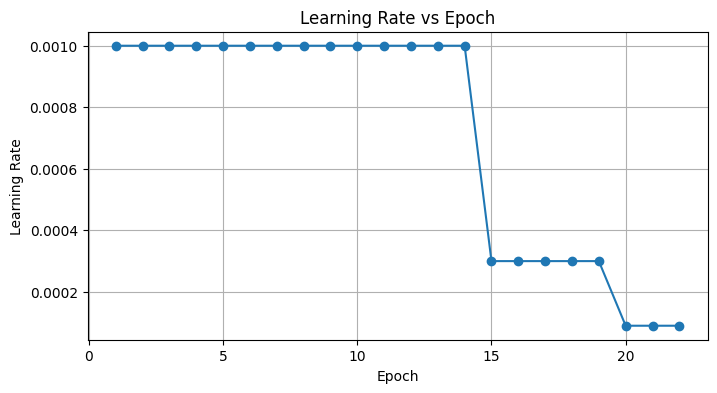

In [ ]:
plt.figure(figsize=(8,4))

if lr_tracker.history_lr:
    plt.plot(range(1, len(lr_tracker.history_lr) + 1), lr_tracker.history_lr, marker='o')
    plt.title("Learning Rate vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.grid(True)
    plt.show()
else:
    print("Learning rate history is empty. Please ensure lr_tracker was used as a callback during model training.")
    plt.close()

# **Merge History**

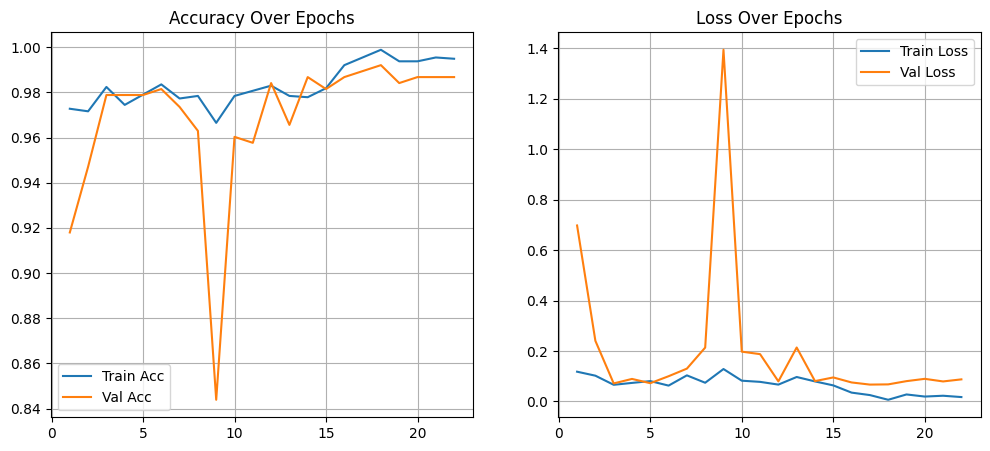

In [ ]:
def merge_history(h1, h2):
    merged = {}
    for k in h1.history.keys():
        merged[k] = h1.history[k] + h2.history[k]
    return merged

hist = merge_history(history1, history2)
ep = range(1, len(hist["accuracy"])+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(ep, hist["accuracy"], label="Train Acc")
plt.plot(ep, hist["val_accuracy"], label="Val Acc")
plt.legend(); plt.grid(); plt.title("Accuracy Over Epochs")

plt.subplot(1,2,2)
plt.plot(ep, hist["loss"], label="Train Loss")
plt.plot(ep, hist["val_loss"], label="Val Loss")
plt.legend(); plt.grid(); plt.title("Loss Over Epochs")

plt.show()


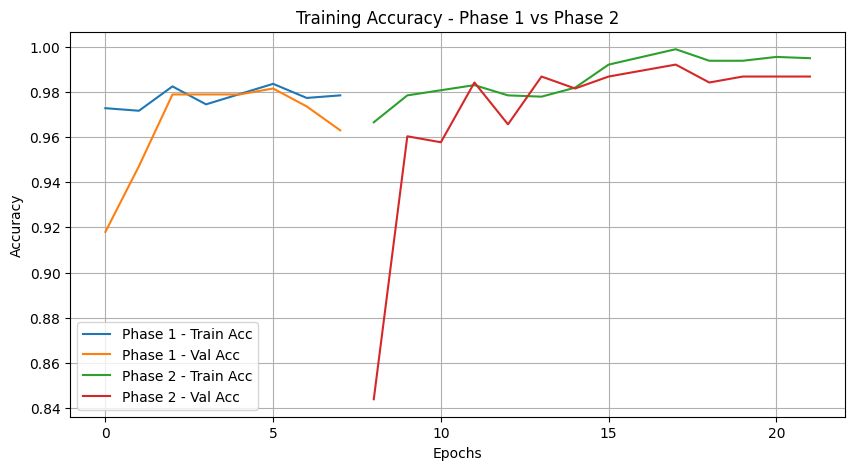

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history1.history["accuracy"], label="Phase 1 - Train Acc")
plt.plot(history1.history["val_accuracy"], label="Phase 1 - Val Acc")
plt.plot([None]*len(history1.history["accuracy"]) + history2.history["accuracy"],
         label="Phase 2 - Train Acc")
plt.plot([None]*len(history1.history["accuracy"]) + history2.history["val_accuracy"],
         label="Phase 2 - Val Acc")
plt.title("Training Accuracy - Phase 1 vs Phase 2")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


# **Confusion Matrix**

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 73s 6s/step - accuracy: 0.9901 - loss: 0.0606
Test Accuracy: 99.21259880065918 %
12/12 ━━━━━━━━━━━━━━━━━━━━ 72s 6s/step
              precision    recall  f1-score   support

     Healthy       1.00      0.99      0.99        79
      Mosaic       0.99      0.99      0.99        70
      RedRot       1.00      1.00      1.00        78
        Rust       1.00      0.99      0.99        78
      Yellow       0.97      1.00      0.99        76

    accuracy                           0.99       381
   macro avg       0.99      0.99      0.99       381
weighted avg       0.99      0.99      0.99       381



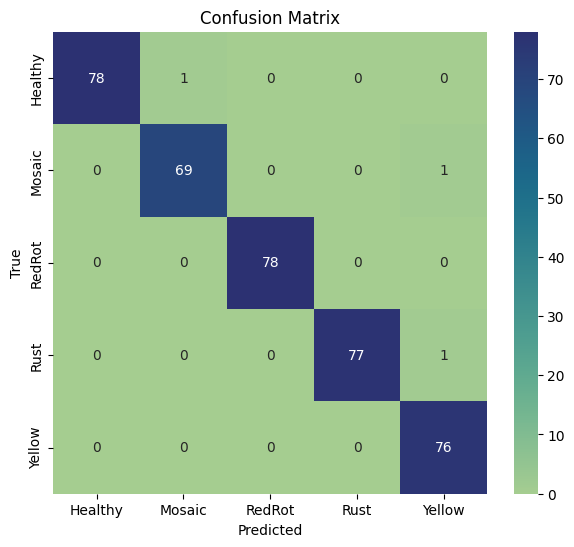

In [ ]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc*100, "%")

y_pred_proba = model.predict(test_gen)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_gen.classes

print(classification_report(y_true, y_pred, target_names=LABELS))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="crest",
            xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from google.colab import drive
import json
import glob
import re
from pathlib import Path

# Mount Google Drive (must do this once per session)
drive.mount('/content/drive')

# Base folder in Drive where checkpoints & models will be stored
DRIVE_BASE = "/content/drive/MyDrive/sugarcane_checkpoints"
Path(DRIVE_BASE).mkdir(parents=True, exist_ok=True)

# Helper: build checkpoint filenames
def checkpoint_filename(phase, epoch):
    # e.g. phase1_epoch_05.keras
    return f"{DRIVE_BASE}/{phase}_epoch_{epoch:03d}.keras"

# Save training state (simple JSON tracking last completed epoch per phase)
STATE_FILE = f"{DRIVE_BASE}/training_state.json"

def save_training_state(phase, last_epoch):
    state = {}
    if Path(STATE_FILE).exists():
        try:
            state = json.loads(Path(STATE_FILE).read_text())
        except Exception:
            state = {}
    state[phase] = int(last_epoch)
    Path(STATE_FILE).write_text(json.dumps(state))

def load_training_state():
    if Path(STATE_FILE).exists():
        try:
            return json.loads(Path(STATE_FILE).read_text())
        except Exception:
            return {}
    return {}

# Find latest checkpoint for a given phase, return (path, epoch) or (None, 0)
_ckpt_re = re.compile(r".*?_epoch_(\d+)\\.keras$")
def latest_checkpoint(phase):
    pattern = f"{DRIVE_BASE}/{phase}_epoch_*.keras"
    files = sorted(glob.glob(pattern))
    if not files:
        return None, 0
    # take last and parse epoch
    latest = files[-1]
    m = _ckpt_re.match(latest)
    if m:
        return latest, int(m.group(1))
    return latest, 0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


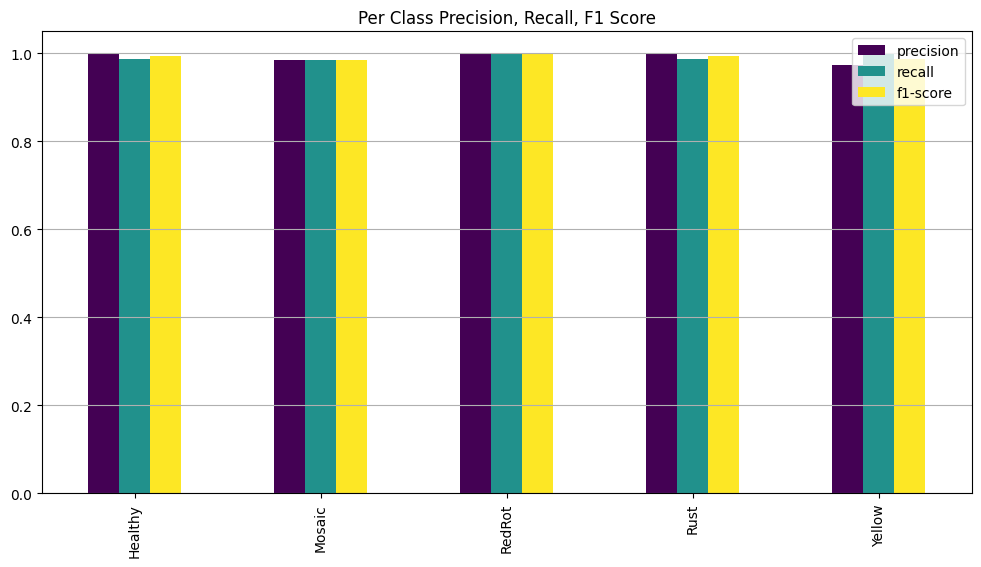

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_true, y_pred, target_names=LABELS, output_dict=True)
df = pd.DataFrame(report).transpose()

df.iloc[:-3][["precision","recall","f1-score"]].plot(
    kind="bar", figsize=(12,6), colormap="viridis"
)

plt.title("Per Class Precision, Recall, F1 Score")
plt.grid(axis="y")
plt.show()


#**ROC CURVE**

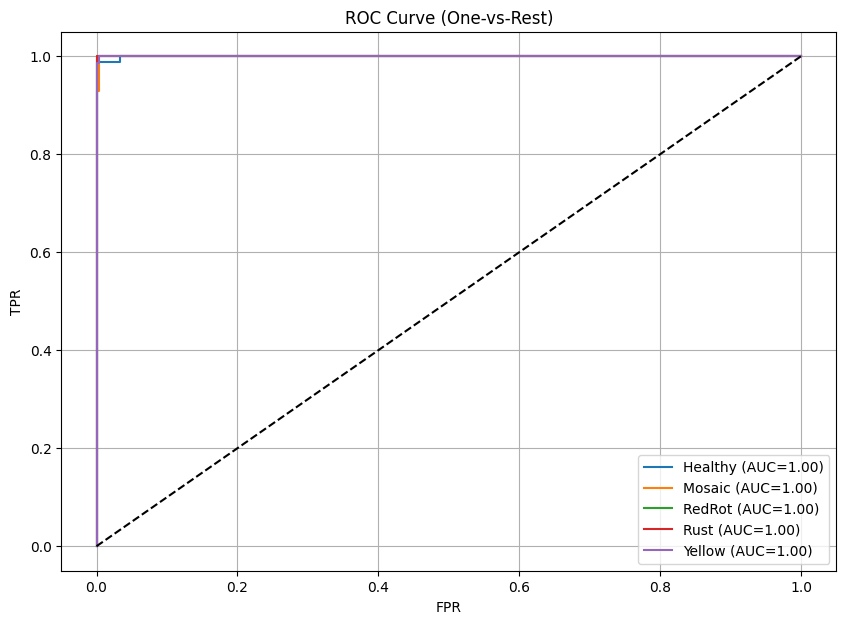

In [ ]:
y_bin = label_binarize(y_true, classes=list(range(len(LABELS))))

plt.figure(figsize=(10,7))

for i in range(len(LABELS)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_pred_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{LABELS[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],"k--")
plt.title("ROC Curve (One-vs-Rest)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()
plt.show()


#  **Misclassified Images**

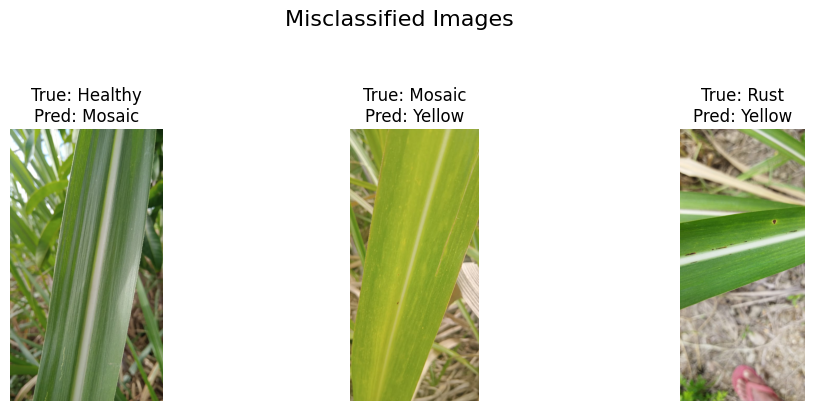

In [ ]:
mis_idx = np.where(y_pred != y_true)[0]

plt.figure(figsize=(12,12))
for i, idx in enumerate(mis_idx[:9]):
    img = Image.open(test_gen.filepaths[idx])

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"True: {LABELS[y_true[idx]]}\nPred: {LABELS[y_pred[idx]]}")
    plt.axis("off")

plt.suptitle("Misclassified Images", fontsize=16)
plt.show()


# **Grad Cam Visualization**

In [ ]:
import cv2
def make_gradcam_heatmap(img_arr, model, last_conv="conv5_block3_out"):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv, preds = grad_model([img_arr])
        class_idx = tf.argmax(preds[0])
        class_output = preds[:, class_idx]

    grads = tape.gradient(class_output, conv)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv = conv[0]
    heatmap = conv @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (heatmap.max() + 1e-10)

    return heatmap

def overlay_heatmap(img, heatmap):
    img = img.resize((224,224))
    img_np = np.array(img)

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap_col = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    out = heatmap_col * 0.4 + img_np
    return Image.fromarray(np.uint8(out))

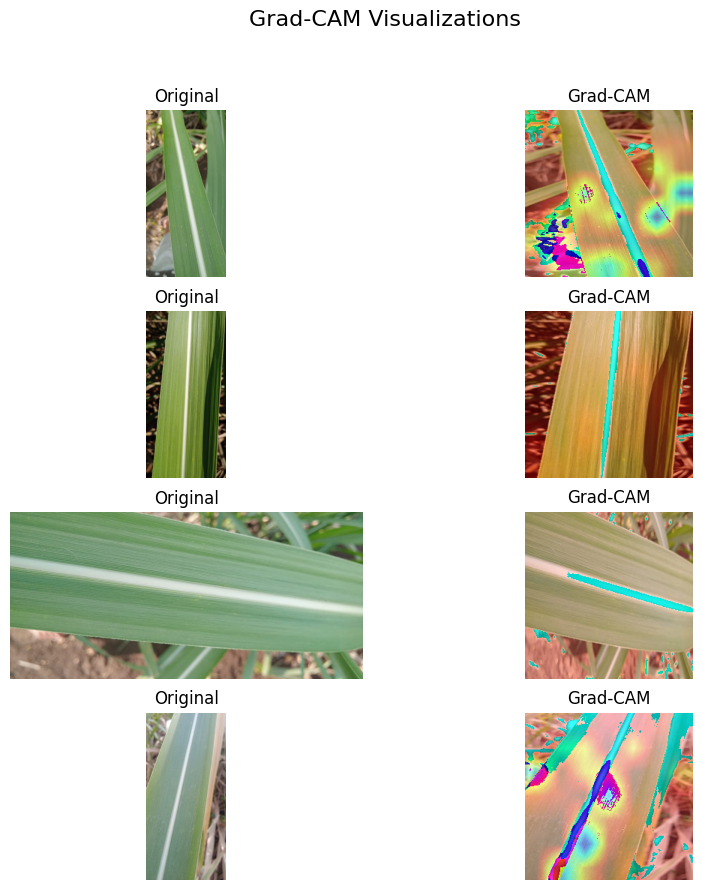

In [ ]:
indices = [0, 10, 20, 30]

plt.figure(figsize=(10,10))

for i, idx in enumerate(indices):
    img = Image.open(test_gen.filepaths[idx]).convert("RGB")

    arr = preprocess_input(
        np.expand_dims(np.array(img.resize((224,224))),0)
    )

    heatmap = make_gradcam_heatmap(arr, model)
    overlay_img = overlay_heatmap(img, heatmap)

    plt.subplot(4,2,2*i+1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(4,2,2*i+2)
    plt.imshow(overlay_img)
    plt.title("Grad-CAM")
    plt.axis("off")

plt.suptitle("Grad-CAM Visualizations", fontsize=16)
plt.show()

# **TEST TIME AUGMENTATION**

In [ ]:
def tta_predict(img):
    views = [
        img,
        img.transpose(Image.FLIP_LEFT_RIGHT),
        img.rotate(15),
        img.rotate(-15),
        img.rotate(30),
        img.rotate(-30)
    ]

    batch = []
    for v in views:
        arr = preprocess_input(
            np.expand_dims(np.array(v.resize((224,224))),0)
        )
        batch.append(arr)

    batch = np.vstack(batch)
    preds = model.predict(batch)
    avg = preds.mean(axis=0)

    return LABELS[np.argmax(avg)], np.max(avg)*100

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 885ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 885ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 875ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 939ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 874ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 883ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 861ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 874ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step
1/1 ━━━━━━━━━━━━━━━━━━

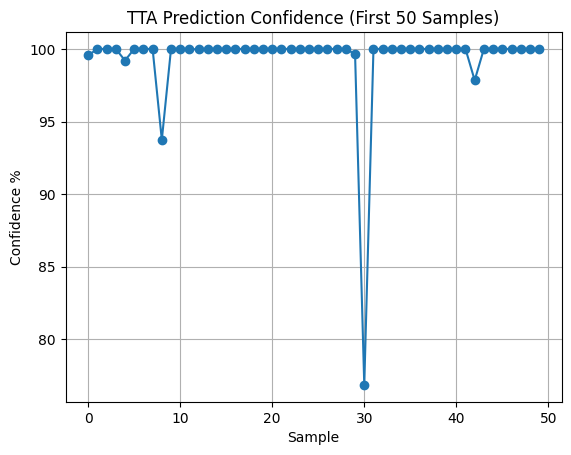

In [ ]:
tta_scores = []

for path in test_gen.filepaths[:50]:
    img = Image.open(path).convert("RGB")
    _, conf = tta_predict(img)
    tta_scores.append(conf)

plt.plot(tta_scores, marker="o")
plt.title("TTA Prediction Confidence (First 50 Samples)")
plt.xlabel("Sample")
plt.ylabel("Confidence %")
plt.grid()
plt.show()

# **Saving Model**

In [ ]:
model_save_path = "/content/drive/MyDrive/Models/resnet50_sugarcane_leaf_model.keras"
labels_save_path = "/content/drive/MyDrive/Models/labels.npy"

model.save(model_save_path)
np.save(labels_save_path, np.array(LABELS))

from google.colab import files
files.download(model_save_path)
files.download(labels_save_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Load Model**

In [3]:

import tensorflow as tf
MODEL_PATH = "/content/drive/MyDrive/Models/resnet50_sugarcane_leaf_model.keras"
sugarcane_model = tf.keras.models.load_model(MODEL_PATH)
sugarcane_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 40,401,292 (154.12 MB)

 Trainable params: 15,631,877 (59.63 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

 Optimizer params: 15,631,879 (59.63 MB)

In [ ]:
!pip install opencv-python-headless==4.8.0.74

Reason for being yanked: deprecated, use 4.8.0.76
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 11.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 2.0.8 requires opencv-python-headless>=4.9.0.80, but you have opencv-python-headless 4.8.0.74 which is incompatible.
albucore 0.0.24 requires opencv-python-headless>=4.9.0.80, but you have opencv-python-headless 4.8.0.74 which is incompatible.


# **Streamlit UI**

In [4]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
from io import BytesIO
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import time
from datetime import datetime, timedelta
import random
import cv2
from PIL import Image

# PAGE CONFIGURATION
st.set_page_config(
    page_title="Sugarcane Leaf Disease Detector",
    layout="wide",
    initial_sidebar_state="expanded"
)

# CUSTOM CSS (Professional & Clean)
st.markdown("""
    <style>
    body {
        font-family: 'Poppins', sans-serif;
    }

    .main-title {
        font-size: 2.8rem;
        text-align: center;
        font-weight: 700;
        margin-bottom: 0.2rem;
        color: #2E7D32;
    }

    .sub-title {
        text-align: center;
        font-size: 1.1rem;
        color: #4CAF50;
        margin-bottom: 1.5rem;
    }

    .stButton>button {
        background: #2E7D32 !important;
        color: white;
        border-radius: 10px !important;
        padding: 10px 25px;
        border: none;
        font-weight: 600;
    }

    .stButton>button:hover {
        background: #1B5E20 !important;
    }

    .card {
        background: white;
        padding: 1.5rem;
        border-radius: 12px;
        box-shadow: 0 4px 12px rgba(0,0,0,0.1);
        margin-bottom: 1rem;
        border-left: 5px solid #2E7D32;
    }

    .stat-card {
        background: #2E7D32;
        color: white;
        padding: 1.2rem;
        border-radius: 10px;
        text-align: center;
        margin: 0.5rem;
    }

    .prediction-card {
        background: #E8F5E9;
        padding: 1.5rem;
        border-radius: 12px;
        margin: 1rem 0;
    }

    .disease-tag {
        display: inline-block;
        padding: 5px 15px;
        border-radius: 15px;
        font-size: 0.9rem;
        font-weight: 600;
        margin-top: 5px;
    }

    .footer {
        text-align: center;
        color: #1B5E20;
        font-size: 0.9rem;
        margin-top: 2rem;
        padding: 1rem;
    }
    </style>
""", unsafe_allow_html=True)

# SESSION STATE INIT
if "logged_in" not in st.session_state:
    st.session_state.logged_in = False

if "page" not in st.session_state:
    st.session_state.page = "login"

if "prediction_history" not in st.session_state:
    st.session_state.prediction_history = []

if "user_feedback" not in st.session_state:
    st.session_state.user_feedback = []

# SIMPLE IN-MEMORY USER DATABASE (You can replace with CSV / SQLite)
users = {"admin@gmail.com": "1234"}

# SAMPLE DATA GENERATION (Dashboard visuals placeholder)
def generate_sample_history():
    diseases = ["Healthy", "Mosaic", "RedRot", "Rust", "Yellow"]
    history = []
    for i in range(10):
        date = datetime.now() - timedelta(days=random.randint(1, 30))
        history.append({
            "date": date,
            "disease": random.choice(diseases),
            "confidence": round(random.uniform(75, 98), 2),
            "image_id": f"img_{i+1}"
        })
    return history

def generate_sample_feedback():
    names = [
        "Raj Kumar", "Priya Sharma", "Amit Patel",
        "Sunil Reddy", "Laxmi Nair", "Karthik M"
    ]
    loc = [
        "Maharashtra", "Karnataka", "Uttar Pradesh",
        "Tamil Nadu", "Andhra Pradesh", "Punjab"
    ]
    text = [
        "Accurate detection helped in early intervention.",
        "Useful tool for crop monitoring.",
        "Interface is clean and easy to use.",
        "The insights are highly beneficial.",
        "Confidence score is helpful.",
        "Great tool for farmers."
    ]
    data = []
    for i in range(6):
        data.append({
            "name": names[i],
            "location": loc[i],
            "feedback": text[i],
            "rating": random.randint(4, 5),
            "date": datetime.now() - timedelta(days=random.randint(1, 60))
        })
    return data

# ---------------- LOGIN PAGE ----------------
def login_page():
    st.markdown("<h1 class='main-title'>Login</h1>", unsafe_allow_html=True)
    st.markdown("<p class='sub-title'>Access the Sugarcane Disease Detection System</p>",
                unsafe_allow_html=True)

    with st.form("login_form"):
        email = st.text_input("Email Address")
        password = st.text_input("Password", type="password")
        login = st.form_submit_button("Login")

        if login:
            if email in users and users[email] == password:
                st.session_state.logged_in = True
                st.session_state.page = "dashboard"
                # Initialize with some dummy data (can be removed later)
                if not st.session_state.prediction_history:
                    st.session_state.prediction_history = generate_sample_history()
                if not st.session_state.user_feedback:
                    st.session_state.user_feedback = generate_sample_feedback()
                st.success("Login successful.")
            else:
                st.error("Invalid email or password.")

    if st.button("Create New Account"):
        st.session_state.page = "signup"

# ---------------- SIGNUP PAGE ----------------
def signup_page():
    st.markdown("<h1 class='main-title'>Create Account</h1>", unsafe_allow_html=True)

    with st.form("signup_form"):
        name = st.text_input("Full Name")
        email = st.text_input("Email Address")
        password = st.text_input("Create Password", type="password")
        confirm = st.text_input("Confirm Password", type="password")
        submit = st.form_submit_button("Register")

        if submit:
            if not email or not password:
                st.error("Email and password are required.")
            elif password == confirm:
                users[email] = password
                st.success("Account created successfully.")
                st.session_state.page = "login"
            else:
                st.error("Passwords do not match.")

    if st.button("Back to Login"):
        st.session_state.page = "login"

# ---------------- LOAD MODEL ----------------
@st.cache_resource
def load_model():
    model_path = "/content/drive/MyDrive/Models/resnet50_sugarcane_leaf_model.keras"
    if not os.path.exists(model_path):
        st.error(f" Model file not found at: {model_path}\n"
                 "Please mount Google Drive and check the path/filename.")
        st.stop()
    return tf.keras.models.load_model(model_path)

model = load_model()
labels = ["Healthy", "Mosaic", "RedRot", "Rust", "Yellow"]

# ---------------- GRAD-CAM FUNCTIONS ----------------
def make_gradcam_heatmap(img_arr, model, last_conv="conv5_block3_out"):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img_arr)
        class_id = tf.argmax(preds[0])
        loss = preds[:, class_id]

    grads = tape.gradient(loss, conv_output)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (heatmap.max() + 1e-10)

    return heatmap

def overlay_gradcam(original_pil_img, heatmap, alpha=0.4):

    if isinstance(heatmap, tf.Tensor):
        heatmap = heatmap.numpy()

    # Resize heatmap to match image size
    heatmap = cv2.resize(heatmap, (original_pil_img.size[0], original_pil_img.size[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img = np.array(original_pil_img)
    if img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    superimposed = cv2.addWeighted(heatmap, alpha, img_bgr, 1 - alpha, 0)
    superimposed = cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)
    return Image.fromarray(superimposed)

# ---------------- DASHBOARD ROOT ----------------
def dashboard():
    with st.sidebar:
        st.header("Navigation")
        selected = st.radio("Menu", [
            "Dashboard",
            "Disease Detection",
            "Analytics",
            "Community",
            "Settings"
        ])

        st.markdown("---")
        st.subheader("Quick Stats")
        total_scans = len(st.session_state.prediction_history)
        st.metric("Total Scans", total_scans)

        if total_scans > 0:
            df_stats = pd.DataFrame(st.session_state.prediction_history)
            healthy_count = (df_stats["disease"] == "Healthy").sum()
            diseased_count = total_scans - healthy_count
        else:
            healthy_count = diseased_count = 0

        st.metric("Healthy Leaves", healthy_count)
        st.metric("Diseased Leaves", diseased_count)

        if st.button("Logout"):
            st.session_state.logged_in = False
            st.session_state.page = "login"

    if selected == "Dashboard":
        show_dashboard()
    elif selected == "Disease Detection":
        show_disease_detection()
    elif selected == "Analytics":
        show_analytics()
    elif selected == "Community":
        show_community()
    elif selected == "Settings":
        show_settings()

# ---------------- DASHBOARD HOME ----------------
def show_dashboard():
    st.markdown("<h1 class='main-title'>System Dashboard</h1>", unsafe_allow_html=True)

    history = st.session_state.prediction_history
    total_scans = len(history)

    if total_scans > 0:
        df = pd.DataFrame(history)
        healthy_count = (df["disease"] == "Healthy").sum()
        diseased_count = total_scans - healthy_count
        active_days = df["date"].dt.date.nunique()
    else:
        healthy_count = diseased_count = active_days = 0

    col1, col2, col3, col4 = st.columns(4)
    col1.markdown(
        f"<div class='stat-card'><h3>Total Scans</h3><h2>{total_scans}</h2></div>",
        unsafe_allow_html=True
    )
    col2.markdown(
        f"<div class='stat-card'><h3>Healthy</h3><h2>{healthy_count}</h2></div>",
        unsafe_allow_html=True
    )
    col3.markdown(
        f"<div class='stat-card'><h3>Diseased</h3><h2>{diseased_count}</h2></div>",
        unsafe_allow_html=True
    )
    col4.markdown(
        f"<div class='stat-card'><h3>Active Days</h3><h2>{active_days}</h2></div>",
        unsafe_allow_html=True
    )

    st.subheader("Recent Scan History")
    if total_scans:
        df_recent = pd.DataFrame(history[:5])
        st.dataframe(df_recent)
    else:
        st.info("No scans available. Go to 'Disease Detection' to perform your first scan.")

# ---------------- DISEASE DETECTION PAGE ----------------
def show_disease_detection():
    st.markdown("<h1 class='main-title'>Disease Detection</h1>", unsafe_allow_html=True)
    st.markdown("<p class='sub-title'>Upload a sugarcane leaf image for prediction</p>",
                unsafe_allow_html=True)

    uploaded_file = st.file_uploader("Choose Leaf Image", type=["jpg", "jpeg", "png"])

    if uploaded_file:
        file_bytes = uploaded_file.read()

        col1, col2 = st.columns(2)

        # Left: Display image
        with col1:
            st.subheader("Uploaded Image")
            img_display = image.load_img(BytesIO(file_bytes), target_size=(224,224))
            st.image(img_display, use_container_width=True)

        # Right: Prediction
        with col2:
            st.subheader("Analysis Result")
            with st.spinner("Processing..."):
                # Real-time prediction speed measurement
                img_model = image.load_img(BytesIO(file_bytes), target_size=(224, 224))
                arr = image.img_to_array(img_model)
                arr = np.expand_dims(arr, axis=0)
                arr = preprocess_input(arr)

                start_time = time.time()
                pred = model.predict(arr)
                end_time = time.time()
                inference_time_ms = (end_time - start_time) * 1000

                idx = np.argmax(pred)
                conf = float(np.max(pred) * 100)
                disease = labels[idx]

            st.markdown("<div class='prediction-card'>", unsafe_allow_html=True)
            st.write(f"Predicted Disease: **{disease}**")
            st.write(f"Confidence: **{conf:.2f}%**")

            # Confidence Score Visualization
            st.write("Model Confidence")
            st.progress(conf / 100.0)

            if conf >= 90:
                st.success("High model confidence ")
            elif conf >= 75:
                st.warning("Moderate model confidence ")
            else:
                st.error("Low model confidence  – please verify with more images.")

            st.write(f"Inference Time: **{inference_time_ms:.1f} ms** (aiming < 1000 ms)")
            st.markdown("</div>", unsafe_allow_html=True)

            # Disease Information
            st.subheader("Disease Information")
            display_disease_info(disease)

            # Grad-CAM Heatmap
            st.subheader("Grad-CAM Heatmap (Model Focus Regions)")
            try:
                heatmap = make_gradcam_heatmap(arr, model)
                gradcam_img = overlay_gradcam(img_display, heatmap)
                st.image(gradcam_img, use_container_width=True,
                         caption="Regions most influential for the prediction")
            except Exception as e:
                st.info("Grad-CAM visualization not available for this model configuration.")
                st.text(f"Details: {str(e)}")

            # Update prediction history (dashboard auto-update)
            entry = {
                "date": datetime.now(),
                "disease": disease,
                "confidence": conf,
                "image_id": f"img_{len(st.session_state.prediction_history)+1}"
            }
            st.session_state.prediction_history.insert(0, entry)

# ---------------- DISEASE INFORMATION ----------------
def display_disease_info(disease):
    info = {
        "Healthy": {
            "desc": "The leaf appears healthy with no signs of abnormality.",
            "symptoms": ["Uniform green color", "No visible spots"],
            "treatment": "No action required."
        },
        "Mosaic": {
            "desc": "Mosaic virus causes light and dark patches.",
            "symptoms": ["Mottled appearance", "Patchy colors"],
            "treatment": "Use disease-free planting material."
        },
        "RedRot": {
            "desc": "Red Rot is a harmful fungal disease.",
            "symptoms": ["Internal red discoloration", "Wilting"],
            "treatment": "Apply recommended fungicide and remove infected canes."
        },
        "Rust": {
            "desc": "Rust creates orange/brown pustules.",
            "symptoms": ["Brown powdery spots", "Premature leaf death"],
            "treatment": "Use resistant varieties and systemic fungicide."
        },
        "Yellow": {
            "desc": "Yellow leaf syndrome affects nutrient uptake.",
            "symptoms": ["Yellowing", "Reduced vigor"],
            "treatment": "Micronutrient supplementation and balanced fertilization required."
        }
    }

    d = info[disease]
    st.write("**Description:**", d["desc"])
    st.write("**Symptoms:**")
    for s in d["symptoms"]:
        st.write("-", s)
    st.write("**Treatment:**", d["treatment"])

# ---------------- ANALYTICS PAGE ----------------
def show_analytics():
    st.markdown("<h1 class='main-title'>Analytics</h1>", unsafe_allow_html=True)

    if not st.session_state.prediction_history:
        st.info("No prediction data available. Perform some scans first.")
        return

    df = pd.DataFrame(st.session_state.prediction_history)

    col1, col2 = st.columns(2)

    # Disease distribution pie chart
    with col1:
        st.subheader("Disease Distribution")
        counts = df["disease"].value_counts()
        fig = px.pie(
            values=counts.values,
            names=counts.index,
            color_discrete_sequence=px.colors.sequential.Greens_r
        )
        st.plotly_chart(fig, use_container_width=True)

    # Confidence distribution histogram
    with col2:
        st.subheader("Confidence Distribution")
        fig = px.histogram(df, x="confidence", nbins=20)
        st.plotly_chart(fig, use_container_width=True)

    # Monthly scan trend line graph
    st.subheader("Monthly Scan Trend")
    df["month"] = pd.to_datetime(df["date"]).dt.to_period("M").astype(str)
    trend = df.groupby("month").size()
    fig = px.line(
        x=trend.index, y=trend.values,
        labels={"x": "Month", "y": "Total Scans"}
    )
    st.plotly_chart(fig, use_container_width=True)

# ---------------- COMMUNITY PAGE ----------------
def show_community():
    st.markdown("<h1 class='main-title'>Community Feedback</h1>", unsafe_allow_html=True)

    for fb in st.session_state.user_feedback:
        st.markdown(
            f"""
            <div class='card'>
                <h4>{fb['name']} ({fb['location']})</h4>
                <p>Rating: {fb['rating']} / 5</p>
                <p>{fb['feedback']}</p>
                <small>{fb['date'].strftime('%Y-%m-%d')}</small>
            </div>
            """,
            unsafe_allow_html=True
        )

    st.subheader("Submit Feedback")
    with st.form("fb_form"):
        name = st.text_input("Your Name")
        location = st.text_input("Location")
        rating = st.slider("Rating", 1, 5, 5)
        text = st.text_area("Feedback")

        submit = st.form_submit_button("Submit")
        if submit and name and text:
            st.session_state.user_feedback.insert(0, {
                "name": name,
                "location": location,
                "rating": rating,
                "feedback": text,
                "date": datetime.now()
            })
            st.success("Feedback submitted.")

# ---------------- SETTINGS PAGE ----------------
def show_settings():
    st.markdown("<h1 class='main-title'>Settings</h1>", unsafe_allow_html=True)

    st.subheader("Preferences")
    theme = st.selectbox("Theme", ["Light", "Dark", "System Default"])
    language = st.selectbox("Language", ["English", "Hindi", "Marathi", "Tamil", "Telugu"])

    st.subheader("Data Management")
    if st.button("Clear Scan History"):
        st.session_state.prediction_history = []
        st.success("Scan history cleared.")

    if st.button("Save Settings"):
        st.success("Settings saved successfully.")

# ---------------- ROUTING LOGIC ----------------
if not st.session_state.logged_in:
    if st.session_state.page == "login":
        login_page()
    else:
        signup_page()
else:
    dashboard()

# ---------------- FOOTER ----------------
st.markdown("""
<div class='footer'>
    <p>Sugarcane Leaf Disease Detector | Powered by Deep Learning</p>
    <p>Designed for smarter agricultural decision-making</p>
</div>
""", unsafe_allow_html=True)


Writing app.py


In [5]:
import numpy as np
import matplotlib.pyplot as plt


# Helper: convert History object or dict to plain dict
def _history_to_dict(h):
    if hasattr(h, "history"):
        return h.history
    elif isinstance(h, dict):
        return h
    else:
        raise ValueError("History must be a Keras History object or dict of metric lists.")

# Combine multiple histories into one


def combine_histories(histories):
    # 1. Collect all metric names
    metric_names = set()
    plain_histories = []

    for phase_name, h in histories:
        hdict = _history_to_dict(h)
        plain_histories.append((phase_name, hdict))
        metric_names |= set(hdict.keys())

    metric_names = sorted(metric_names)
    combined = {m: [] for m in metric_names}
    epochs = []
    phase_spans = []

    offset = 0
    for phase_name, hdict in plain_histories:
        # length of this phase (number of epochs)
        phase_len = len(next(iter(hdict.values())))
        start_epoch = offset + 1
        end_epoch = offset + phase_len
        phase_spans.append((phase_name, start_epoch, end_epoch))

        # extend metric values, filling missing with NaN
        for m in metric_names:
            vals = hdict.get(m, [])
            vals = list(vals)
            if len(vals) < phase_len:
                vals += [np.nan] * (phase_len - len(vals))
            combined[m].extend(vals)

        # epoch numbering
        epochs.extend(list(range(start_epoch, end_epoch + 1)))
        offset += phase_len

    return combined, epochs, phase_spans

In [ ]:

# Plot per-phase history

def plot_phase_histories(histories):
    """
    histories: list of (phase_name, history_or_dict)
    Each phase will get its own Accuracy/Loss subplot figure.
    """
    for phase_name, h in histories:
        hdict = _history_to_dict(h)
        acc = hdict.get("accuracy", None)
        val_acc = hdict.get("val_accuracy", None)
        loss = hdict.get("loss", None)
        val_loss = hdict.get("val_loss", None)

        # Decide number of epochs
        if acc is not None:
            epochs = range(1, len(acc) + 1)
        elif loss is not None:
            epochs = range(1, len(loss) + 1)
        else:
            print(f"No 'accuracy' or 'loss' found for phase: {phase_name}")
            continue

        plt.figure(figsize=(12, 4))
        plt.suptitle(f"Training History for {phase_name}", fontsize=14)

        # Accuracy plot
        plt.subplot(1, 2, 1)
        if acc is not None:
            plt.plot(epochs, acc, label="Train Acc")
        if val_acc is not None:
            plt.plot(epochs, val_acc, label="Val Acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy")
        plt.grid(True)
        plt.legend()

        # Loss plot
        plt.subplot(1, 2, 2)
        if loss is not None:
            plt.plot(epochs, loss, label="Train Loss")
        if val_loss is not None:
            plt.plot(epochs, val_loss, label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

In [6]:
#Plot combined overall history
def plot_combined_history(histories):

    combined, epochs, phase_spans = combine_histories(histories)

    acc = combined.get("accuracy", None)
    val_acc = combined.get("val_accuracy", None)
    loss = combined.get("loss", None)
    val_loss = combined.get("val_loss", None)

    plt.figure(figsize=(14,5))

    #  Accuracy
    plt.subplot(1,2,1)
    if acc is not None:
        plt.plot(epochs, acc, label="Train Acc")
    if val_acc is not None:
        plt.plot(epochs, val_acc, label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Overall Accuracy (All Phases Combined)")
    plt.grid(True)
    plt.legend()

    # Vertical lines at phase transitions
    for i, (name, start, end) in enumerate(phase_spans):
        if i > 0:
            plt.axvline(x=start-0.5, color="gray", linestyle="--", alpha=0.5)
            plt.text(start, plt.ylim()[1]*0.95, f"{name} start", rotation=90,
                     verticalalignment="top", fontsize=8, color="gray")

    # Loss
    plt.subplot(1,2,2)
    if loss is not None:
        plt.plot(epochs, loss, label="Train Loss")
    if val_loss is not None:
        plt.plot(epochs, val_loss, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Overall Loss (All Phases Combined)")
    plt.grid(True)
    plt.legend()

    # Vertical lines again
    for i, (name, start, end) in enumerate(phase_spans):
        if i > 0:
            plt.axvline(x=start-0.5, color="gray", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


    if acc is not None and val_acc is not None:
        print(f"Final Train Acc: {acc[-1]:.4f}, Final Val Acc: {val_acc[-1]:.4f}")
    if loss is not None and val_loss is not None:
        print(f"Final Train Loss: {loss[-1]:.4f}, Final Val Loss: {val_loss[-1]:.4f}")
    print("\nPhase ranges (epoch numbers):")
    for name, start, end in phase_spans:
        print(f"  - {name}: epochs {start} to {end}")

In [7]:
!pip install streamlit pyngrok -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 115.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.5/212.5 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 167.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 4.5 MB/s eta 0:00:00
error: uninstall-distutils-installed-package

× Cannot uninstall blinker 1.4
╰─> It is a distutils installed project and thus we cannot accurately determine which files belong to it which would lead to only a partial uninstall.


In [ ]:
!ls

app.py	drive  sample_data


In [ ]:
!pkill streamlit 2>/dev/null || echo "no streamlit running"
!pkill ngrok 2>/dev/null || echo "no ngrok running"

In [ ]:
!pip install --force-reinstall "numpy==1.26.4" "opencv-python-headless==4.8.0.74"

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached opencv_python_headless-4.8.0.74-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
Reason for being yanked: deprecated, use 4.8.0.76
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached opencv_python_headless-4.8.0.74-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (49.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.8.0.74
    Uninstalling opencv-python-headless-4.8.0.74:
      Successfully uninstalled opencv-python-headless-4.8.0.74
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the

In [ ]:
!pip uninstall -y opencv-python opencv-python-headless
!pip install "numpy==1.26.4" "opencv-python-headless==4.8.0.74" --force-reinstall

Found existing installation: opencv-python-headless 4.8.0.74
Uninstalling opencv-python-headless-4.8.0.74:
  Successfully uninstalled opencv-python-headless-4.8.0.74
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached opencv_python_headless-4.8.0.74-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
Reason for being yanked: deprecated, use 4.8.0.76
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached opencv_python_headless-4.8.0.74-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (49.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires

In [ ]:
import numpy as np
import cv2
import streamlit as st
from pyngrok import ngrok

print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

NumPy: 2.0.2
OpenCV: 4.12.0


In [ ]:
ngrok.kill()

In [8]:
from pyngrok import ngrok
import time
from google.colab import userdata

ngrok.set_auth_token(userdata.get('NGROK_AUTH_TOKEN'))

!pkill streamlit || echo
!killall ngrok || echo
!streamlit run app.py --server.port 8502 --server.address 0.0.0.0 &>/dev/null&

public_url = ngrok.connect(8502,"http")
print("🔗 Public URL:", public_url)
time.sleep(5)


ngrok: no process found

🔗 Public URL: NgrokTunnel: "https://knowable-consuelo-unrallied.ngrok-free.dev" -> "http://localhost:8502"


In [ ]:
!ps aux | grep streamlit

root        2270 22.1  0.5 232608 70412 ?        S    08:11   0:03 /usr/bin/python3 /usr/local/bin/streamlit run app.py --server.port 8502 --server.address 0.0.0.0
root        2339  0.0  0.0   7376  3416 ?        S    08:11   0:00 /bin/bash -c ps aux | grep streamlit
root        2341  0.0  0.0   6484  2412 ?        R    08:11   0:00 grep streamlit
